
# การขยายแหล่งข้อมูล

การใช้แหล่งข้อมูลที่กำหนดเอง

ตัวอย่างนี้จะสาธิตวิธีการขยาย Earth2Studio โดยการนำข้อมูลที่กำหนดเองไปใช้
แหล่งเพื่อใช้ใน workflow ในตัว

ในตัวอย่างนี้คุณจะได้เรียนรู้:

- ข้อกำหนด API ของแหล่งข้อมูล
- การใช้แหล่งข้อมูลที่กำหนดเอง


In [1]:
# /// script
# dependencies = [
#   "earth2studio[fcn] @ git+https://github.com/NVIDIA/earth2studio.git",
#   "cartopy",
#   "scipy",
# ]
# ///

## แหล่งข้อมูลที่กำหนดเอง
Earth2Studio กำหนด APIs ที่จำเป็นสำหรับแหล่งข้อมูลใน
:py:class:`earth2studio.data.base.Datasource` ซึ่งต้องการเพียงฟังก์ชันการโทร
สำหรับตัวอย่างนี้ เราจะพิจารณาขยายแหล่งข้อมูลระยะไกลที่มีอยู่ด้วย
สนามบรรยากาศอีกสนามหนึ่งที่เราคำนวณได้

แหล่งข้อมูล :py:class:`earth2studio.data.ARCO` จัดเตรียมชุดข้อมูล ERA5 ในระบบคลาวด์
รูปแบบที่เหมาะสมที่สุด แต่ให้ความชื้นเฉพาะเท่านั้น นี่เป็นปัญหาสำหรับ
รุ่นที่อาจใช้ความชื้นสัมพัทธ์เป็นอินพุต ตามเอกสาร ECMWF เราสามารถทำได้
คำนวณความชื้นสัมพัทธ์ตามอุณหภูมิและศักยภาพทางภูมิศาสตร์



In [2]:
import os

os.makedirs("outputs", exist_ok=True)
from dotenv import load_dotenv

load_dotenv()  # สิ่งที่ต้องทำ: สร้างฟังก์ชันการเตรียมตัวอย่างทั่วไป

from datetime import datetime

import numpy as np
import xarray as xr

from earth2studio.data import ARCO, GFS
from earth2studio.data.utils import prep_data_inputs
from earth2studio.utils.type import TimeArray, VariableArray


class CustomDataSource:
    """Custom ARCO datasource"""

    relative_humidity_ids = [
        "r50",
        "r100",
        "r150",
        "r200",
        "r250",
        "r300",
        "r400",
        "r500",
        "r600",
        "r700",
        "r850",
        "r925",
        "r1000",
    ]

    def __init__(self, cache: bool = True, verbose: bool = True):
        self.arco = ARCO(cache, verbose)

    def __call__(
        self,
        time: datetime | list[datetime] | TimeArray,
        variable: str | list[str] | VariableArray,
    ) -> xr.DataArray:
        """Function to get data.

        Parameters
        ----------
        time : datetime | list[datetime] | TimeArray
            Timestamps to return data for (UTC).
        variable : str | list[str] | VariableArray
            String, list of strings or array of strings that refer to variables to
            return. Must be in IFS lexicon.

        Returns
        -------
        xr.DataArray
        """
        time, variable = prep_data_inputs(time, variable)

        # แทนที่ความชื้นสัมพัทธ์ด้วยอุณหภูมิตามลำดับ
        # และเขตความชื้นเฉพาะ
        variable_expanded = []
        for v in variable:
            if v in self.relative_humidity_ids:
                level = int(v[1:])
                variable_expanded.extend([f"t{level}", f"q{level}"])
            else:
                variable_expanded.append(v)
        variable_expanded = list(set(variable_expanded))

        # ดึงข้อมูลจาก ARCO
        da_exp = self.arco(time, variable_expanded)

        # คำนวณความชื้นสัมพัทธ์เมื่อจำเป็น
        arrays = []
        for v in variable:
            if v in self.relative_humidity_ids:
                level = int(v[1:])
                t = da_exp.sel(variable=f"t{level}").values
                q = da_exp.sel(variable=f"q{level}").values
                rh = self.calc_relative_humdity(t, q, 100 * level)
                arrays.append(rh)
            else:
                arrays.append(da_exp.sel(variable=v).values)

        da = xr.DataArray(
            data=np.stack(arrays, axis=1),
            dims=["time", "variable", "lat", "lon"],
            coords=dict(
                time=da_exp.coords["time"].values,
                variable=np.array(variable),
                lat=da_exp.coords["lat"].values,
                lon=da_exp.coords["lon"].values,
            ),
        )
        return da

    def calc_relative_humdity(
        self, temperature: np.array, specific_humidity: np.array, pressure: float
    ) -> np.array:
        """Relative humidity calculation

        Parameters
        ----------
        temperature : np.array
            Temperature field (K)
        specific_humidity : np.array
            Specific humidity field (g.kg-1)
        pressure : float
            Pressure (Pa)

        Returns
        -------
        np.array
        """
        epsilon = 0.621981
        p = pressure
        q = specific_humidity
        t = temperature

        e = (p * q * (1.0 / epsilon)) / (1 + q * (1.0 / (epsilon) - 1))

        es_w = 611.21 * np.exp(17.502 * (t - 273.16) / (t - 32.19))
        es_i = 611.21 * np.exp(22.587 * (t - 273.16) / (t + 0.7))

        alpha = np.clip((t - 250.16) / (273.16 - 250.16), 0, 1.2) ** 2
        es = alpha * es_w + (1 - alpha) * es_i
        rh = 100 * e / es

        return rh

/home/siamai/earth2studio-project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/siamai/earth2studio-project/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


### API ของ :py:func:`__call__`
ฟังก์ชันการโทรคือ API หลักของแหล่งข้อมูลซึ่งส่งคืนอาร์เรย์ข้อมูล Xarray
ด้วยข้อมูลที่ร้องขอ สำหรับแหล่งข้อมูลที่กำหนดเองนี้ เราจะดักจับความชื้นสัมพัทธ์
แทนที่ด้วยอุณหภูมิและความชื้นจำเพาะ จากนั้นจึงคำนวณ
ความชื้นสัมพัทธ์จากทุ่งเหล่านี้ โปรดทราบว่ากำลังจัดการแหล่งข้อมูล ARCO
ความซับซ้อนระยะไกล เราแค่จัดการกับอาร์เรย์ Numpy



### :py:func:`calc_relative_humdity`
ขึ้นอยู่กับการคำนวณที่ ECMWF ใช้ในโปรแกรมจำลองเชิงตัวเลขของ IFS ซึ่งจะพิจารณา
เพื่อประเมินไอน้ำและน้ำแข็งที่มีอยู่ในบรรยากาศ

<div class="alert alert-info"><h4>หมายเหตุ</h4><p>ดูข้อมูลอ้างอิง สมการ 7.98 เป็นต้นไป:
https://www.ecmwf.int/en/elibrary/81370-ifs-documentation-cy48r1-part-iv-physical-processes</p></div>



## การยืนยัน
ก่อนที่จะเสียบสิ่งนี้เข้ากับ workflow ของเรา มาตรวจสอบแหล่งข้อมูลของเราอย่างรวดเร็วก่อน
สอดคล้องกับเวลาที่ GFS ให้ความชื้นสัมพัทธ์



In [3]:
ds = CustomDataSource()
da_custom = ds(time=datetime(2022, 1, 1, hour=0), variable=["r500"])

ds_gfs = GFS()
da_gfs = ds_gfs(time=datetime(2022, 1, 1, hour=0), variable=["r500"])

print(da_custom)

2026-04-26 21:11:49.290 | DEBUG    | earth2studio.data.arco:_async_init:131 - Using Multi-Storage Client for ARCO data access


Fetching ARCO data:   0%|          | 0/2 [00:00<?, ?it/s]

2026-04-26 21:11:55.394 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: q500 at 2022-01-01T00:00:00
2026-04-26 21:11:55.396 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: t500 at 2022-01-01T00:00:00


Fetching ARCO data:   0%|          | 0/2 [00:00<?, ?it/s]

2026-04-26 21:11:55.656 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3/specific_humidity/1069440.0.0.0 to local cache
2026-04-26 21:11:55.661 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3/temperature/1069440.0.0.0 to local cache


Fetching GFS data:   0%|          | 0/1 [00:00<?, ?it/s]

2026-04-26 21:12:07.433 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20220101/00/atmos/gfs.t00z.pgrb2.0p25.f000 259807518-809409


Fetching GFS data: 100%|██████████| 1/1 [00:03<00:00,  3.27s/it]

<xarray.DataArray (time: 1, variable: 1, lat: 721, lon: 1440)> Size: 8MB
array([[[[ 28.01413468,  28.01413468,  28.01413468, ...,  28.01413468,
           28.01413468,  28.01413468],
         [ 29.75579658,  29.75314258,  29.81191126, ...,  29.77167483,
           29.76636404,  29.76376009],
         [ 31.28908409,  31.28075462,  31.27237381, ...,  31.31699177,
           31.30860053,  31.29746972],
         ...,
         [ 97.36539026,  97.35685903,  97.39891442, ...,  97.34011022,
           97.32321665,  97.31468906],
         [ 97.50236648,  97.49380369,  97.54603948, ...,  97.5280597 ,
           97.51949448,  97.51949448],
         [102.58417544, 102.58417544, 102.58417544, ..., 102.58417544,
          102.58417544, 102.58417544]]]])
Coordinates:
  * time      (time) datetime64[ns] 8B 2022-01-01
  * variable  (variable) <U4 16B 'r500'
  * lat       (lat) float64 6kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon       (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.0 359.2 359

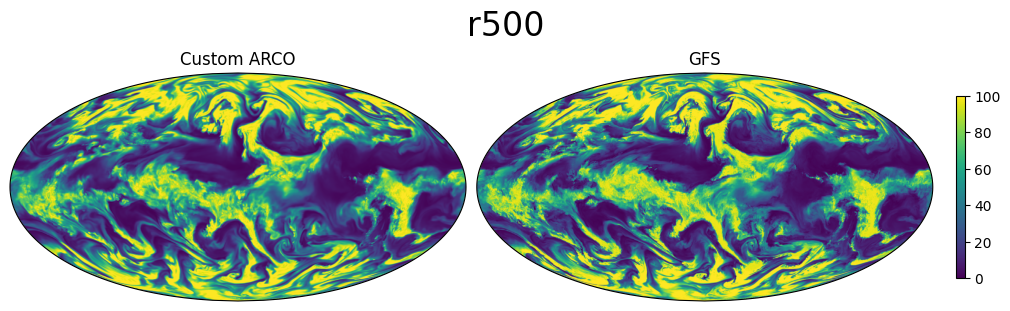

In [4]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    1,
    2,
    figsize=(10, 3),
    subplot_kw={"projection": ccrs.Mollweide()},
    constrained_layout=True,
)

ax[0].imshow(
    da_custom.sel(variable="r500")[0], transform=ccrs.PlateCarree(), vmin=0, vmax=100
)
ax[1].imshow(
    da_gfs.sel(variable="r500")[0], transform=ccrs.PlateCarree(), vmin=0, vmax=100
)

ax[0].set_title("Custom ARCO")
ax[1].set_title("GFS")
plt.suptitle("r500", fontsize=24)
cbar = plt.cm.ScalarMappable()
cbar.set_array(da_custom.sel(variable="r500")[0])
cbar.set_clim(0, 100)
cbar = fig.colorbar(cbar, ax=ax[-1], orientation="vertical", shrink=0.8)

plt.savefig("outputs/03_custom_datasource_gfs_versus_custom.jpg")

## ดำเนินการเวิร์กโฟลว์
เราจะใช้แหล่งข้อมูลที่กำหนดเองนี้เพื่อรัน deterministic inference ด้วยโมเดลที่
ต้องการความชื้นสัมพัทธ์ :mod:`earth2studio.models.px.FCN` เป็นหนึ่งในโมเดลดังกล่าว เนื่องจาก
เรากำลังใช้ ARCO เราสามารถรัน inference ได้ย้อนกลับไปในอดีต

มาสร้างอินสแตนซ์ของคอมโพเนนต์ที่จำเป็นกัน

- Prognostic Model: ใช้ FourCastNet รุ่น :py:class:`earth2studio.models.px.FCN` ในตัว
- Datasource: แหล่งข้อมูลที่กำหนดเองด้านบน
- IO Backend: บันทึกเอาต์พุตลงในร้านค้า Zarr :py:class:`earth2studio.io.ZarrBackend`



In [5]:
from dotenv import load_dotenv

load_dotenv()  # สิ่งที่ต้องทำ: สร้างฟังก์ชันการเตรียมตัวอย่างทั่วไป

import earth2studio.run as run
from earth2studio.io import ZarrBackend
from earth2studio.models.px import FCN

package = FCN.load_default_package()
model = FCN.load_model(package)

# สร้างแหล่งข้อมูล
data = CustomDataSource()

# สร้างตัวจัดการ IO เก็บไว้ในหน่วยความจำ
io = ZarrBackend()

nsteps = 4
io = run.deterministic(["1993-04-05"], nsteps, model, data, io)

print(io.root.tree())

Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.
CuPy distance computation test failed with error: cuVS >= 24.12 or pylibraft < 24.12 should be installed to use this feature
2026-04-26 21:12:21.221 | DEBUG    | earth2studio.data.arco:_async_init:131 - Using Multi-Storage Client for ARCO data access
2026-04-26 21:12:27.130 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-04-26 21:12:27.130 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda


Fetching ARCO data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-04-26 21:12:27.155 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: u10m at 1993-04-05T00:00:00
2026-04-26 21:12:27.156 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: q850 at 1993-04-05T00:00:00
2026-04-26 21:12:27.158 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: u100m at 1993-04-05T00:00:00
2026-04-26 21:12:27.159 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: t850 at 1993-04-05T00:00:00
2026-04-26 21:12:27.160 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: msl at 1993-04-05T00:00:00
2026-04-26 21:12:27.161 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: sp at 1993-04-05T00:00:00
2026-04-26 21:12:27.162 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: v100m at 1993-0

Fetching ARCO data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-04-26 21:12:27.495 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3/100m_u_component_of_wind/817488.0.0 to local cache
2026-04-26 21:12:27.516 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3/specific_humidity/817488.0.0.0 to local cache


...

2026-04-26 21:12:30.111 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3/u_component_of_wind/817488.0.0.0 to local cache
2026-04-26 21:12:30.205 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3/temperature/817488.0.0.0 to local cache
2026-04-26 21:12:30.219 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3/10m_v_component_of_wind/817488.0.0 to local cache


Fetching ARCO data: 100%|██████████| 26/26 [00:41<00:00,  1.59s/it]


2026-04-26 21:13:08.612 | SUCCESS  | earth2studio.run:deterministic:109 - Fetched data from CustomDataSource
2026-04-26 21:13:08.629 | INFO     | earth2studio.run:deterministic:139 - Inference starting!


Running inference: 100%|██████████| 5/5 [00:04<00:00,  1.21it/s]

2026-04-26 21:13:12.751 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete
/
├── lat (720,) float64
├── lead_time (5,) timedelta64[h]
├── lon (1440,) float64
├── msl (1, 5, 720, 1440) float32
├── r500 (1, 5, 720, 1440) float32
├── r850 (1, 5, 720, 1440) float32
├── sp (1, 5, 720, 1440) float32
├── t250 (1, 5, 720, 1440) float32
├── t2m (1, 5, 720, 1440) float32
├── t500 (1, 5, 720, 1440) float32
├── t850 (1, 5, 720, 1440) float32
├── tcwv (1, 5, 720, 1440) float32
├── time (1,) datetime64[ns]
├── u1000 (1, 5, 720, 1440) float32
├── u100m (1, 5, 720, 1440) float32
├── u10m (1, 5, 720, 1440) float32
├── u250 (1, 5, 720, 1440) float32
├── u500 (1, 5, 720, 1440) float32
├── u850 (1, 5, 720, 1440) float32
├── v1000 (1, 5, 720, 1440) float32
├── v100m (1, 5, 720, 1440) float32
├── v10m (1, 5, 720, 1440) float32
├── v250 (1, 5, 720, 1440) float32
├── v500 (1, 5, 720, 1440) float32
├── v850 (1, 5, 720, 1440) float32
├── z1000 (1, 5, 720, 1440) float32
├── z250 (1, 5, 720, 14

## การทำ Post-Processing
เพื่อยืนยันว่าโมเดลของเราทำงานตามที่คาดไว้ เราจะพล็อตคอลัมน์น้ำทั้งหมด
สนามไอเพียงไม่กี่ขั้นตอน



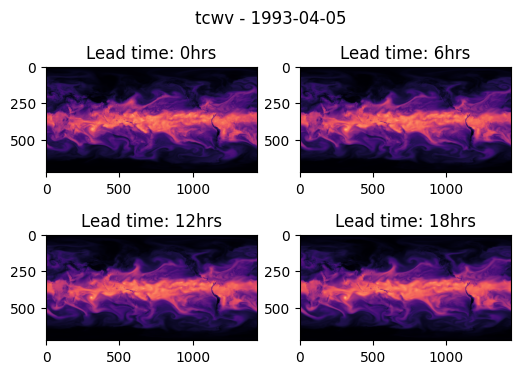

In [6]:
forecast = "1993-04-05"
variable = "tcwv"

plt.close("all")

# สร้างรูปและแกนด้วย projection ที่ระบุ
fig, ax = plt.subplots(2, 2, figsize=(6, 4))

# พล็อต tcwv ทุก 6 ชั่วโมง
ax[0, 0].imshow(io[variable][0, 0], vmin=0, vmax=80, cmap="magma")
ax[0, 1].imshow(io[variable][0, 1], vmin=0, vmax=80, cmap="magma")
ax[1, 0].imshow(io[variable][0, 2], vmin=0, vmax=80, cmap="magma")
ax[1, 1].imshow(io[variable][0, 3], vmin=0, vmax=80, cmap="magma")

# ตั้งชื่อเรื่อง
plt.suptitle(f"{variable} - {forecast}")
times = (
    io["lead_time"][:].astype("timedelta64[ns]").astype("timedelta64[h]").astype(int)
)
ax[0, 0].set_title(f"Lead time: {times[0]}hrs")
ax[0, 1].set_title(f"Lead time: {times[1]}hrs")
ax[1, 0].set_title(f"Lead time: {times[2]}hrs")
ax[1, 1].set_title(f"Lead time: {times[3]}hrs")

plt.savefig("outputs/03_custom_datasource_prediction.jpg", bbox_inches="tight")